<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_memory_readout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D14_MEMORY_READOUT — Memory Reads Back Into Wave Output

This notebook tests whether stored field memory can be read back into an output wave sequence.

Previous experiment:

D13_WAVE_TO_MEMORY showed that a transmitted wave signal can be decoded and written into bounded memory slots.

This experiment performs the reverse direction.

Stored memory slots are scanned one by one and converted back into a wave output.

Expected result:

STORED_SEQUENCE = 10110101  
READOUT_SEQUENCE = 10110101  

STATE = READOUT_LOCKED

STATE: READOUT_LOCKED
stored sequence: 10110101
readout sequence: 10110101
readout accuracy: 1.0


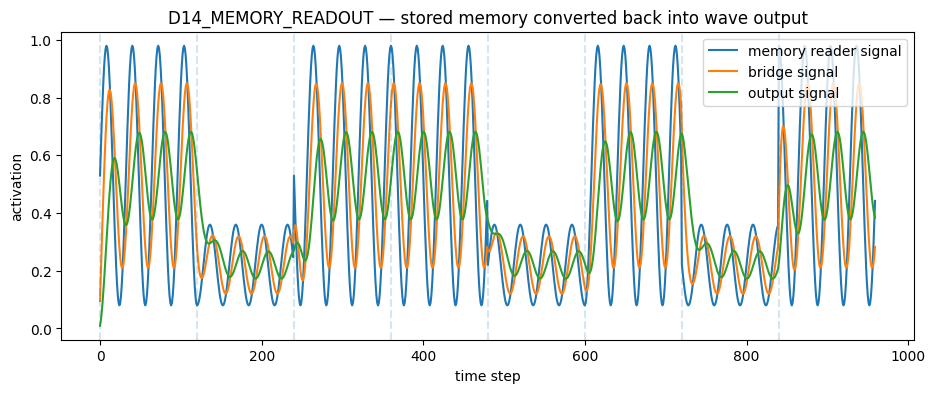

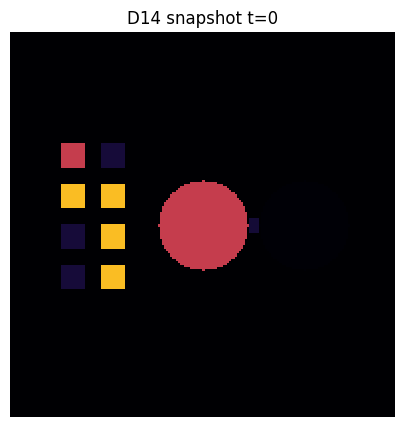

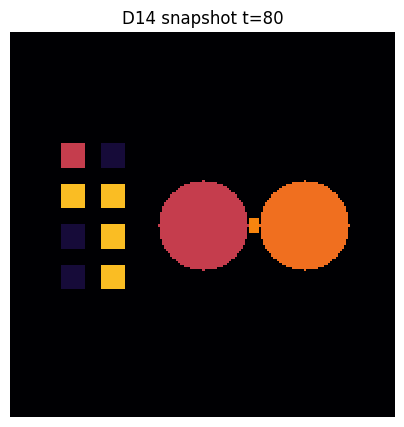

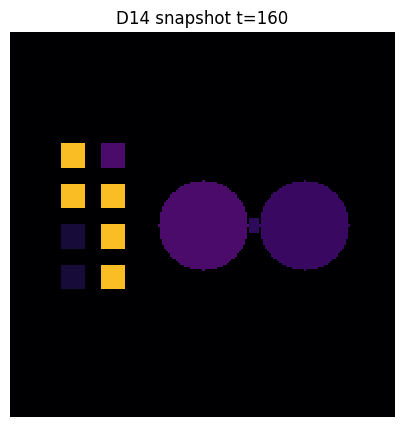

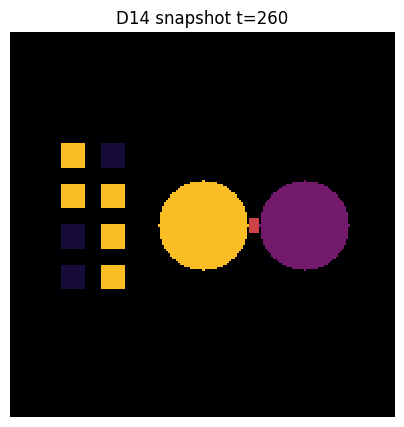

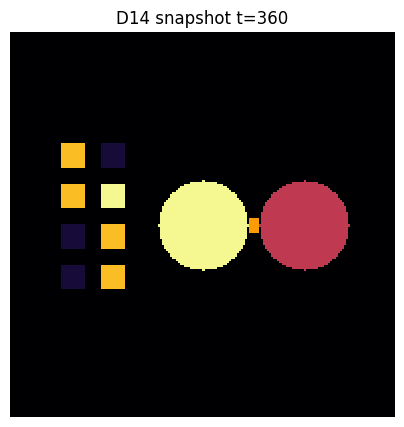

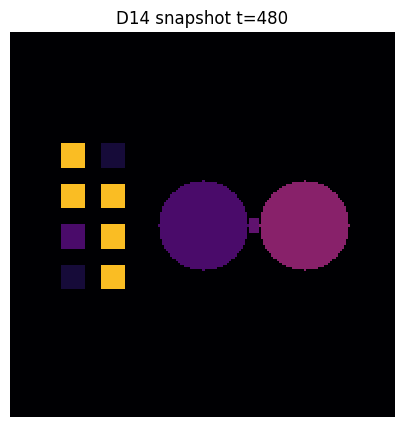

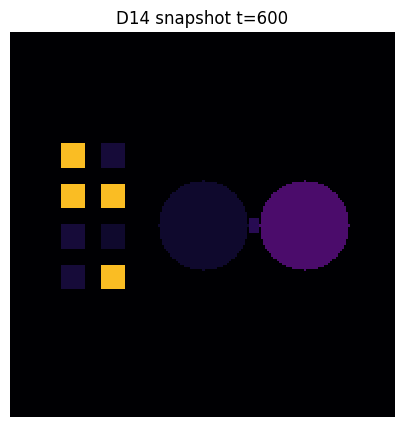

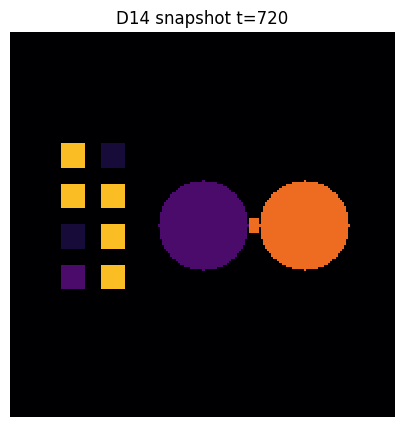

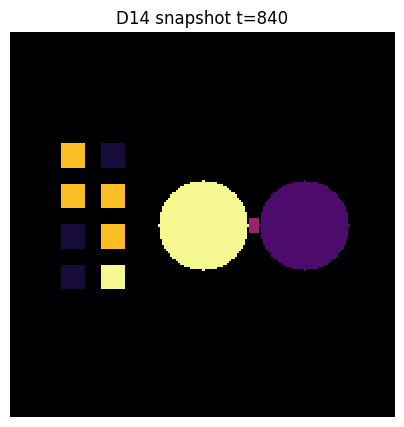

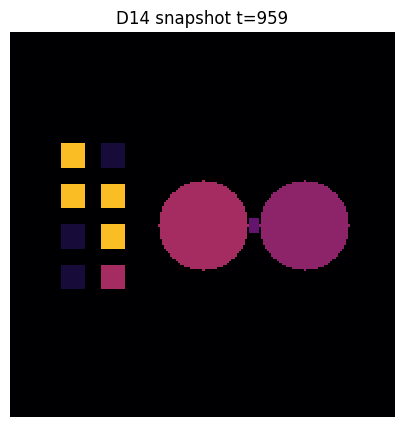

Readout bits:


,STATE,BIT_INDEX,MEMORY_BIT,OUTPUT_MEAN,READOUT_BIT,MATCH
0,D14_MEMORY_READOUT,0,1,0.541,1,1
1,D14_MEMORY_READOUT,1,0,0.218,0,1
2,D14_MEMORY_READOUT,2,1,0.515,1,1
3,D14_MEMORY_READOUT,3,1,0.540,1,1
4,D14_MEMORY_READOUT,4,0,0.225,0,1
5,D14_MEMORY_READOUT,5,1,0.518,1,1
6,D14_MEMORY_READOUT,6,0,0.218,0,1
7,D14_MEMORY_READOUT,7,1,0.538,1,1


Summary:


,STATE,RESULT,STORED_SEQUENCE,READOUT_SEQUENCE,READOUT_ACCURACY,BIT_LEN,DECODE_DELAY,DECODE_THRESHOLD
0,D14_MEMORY_READOUT,READOUT_LOCKED,10110101,10110101,1.0,120,35,0.38


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def make_readout_masks(size=190, radius=22, memory_slots=8):
    Y, X = np.ogrid[:size, :size]

    center_reader = (95, size // 2)
    center_output = (145, size // 2)

    dist_reader = np.sqrt((X - center_reader[0]) ** 2 + (Y - center_reader[1]) ** 2)
    dist_output = np.sqrt((X - center_output[0]) ** 2 + (Y - center_output[1]) ** 2)

    reader_cell = dist_reader <= radius
    output_cell = dist_output <= radius

    bridge = (
        (Y >= size // 2 - 3)
        & (Y <= size // 2 + 3)
        & (X > center_reader[0] + radius)
        & (X < center_output[0] - radius)
    )

    memory_masks = []

    start_x = 25
    start_y = 55
    slot_size = 12
    gap = 8

    for i in range(memory_slots):
        row = i // 2
        col = i % 2

        x0 = start_x + col * (slot_size + gap)
        y0 = start_y + row * (slot_size + gap)

        slot = (
            (X >= x0)
            & (X < x0 + slot_size)
            & (Y >= y0)
            & (Y < y0 + slot_size)
        )

        memory_masks.append(slot)

    return reader_cell, output_cell, bridge, memory_masks


def render_readout_field(
    size,
    reader_cell,
    output_cell,
    bridge,
    memory_masks,
    memory_values,
    selected_index,
    reader_activation,
    bridge_activation,
    output_activation,
):
    field = np.zeros((size, size), dtype=float)

    for i, mask in enumerate(memory_masks):
        if i == selected_index:
            field[mask] = reader_activation
        else:
            field[mask] = 0.10 + 0.75 * memory_values[i]

    field[reader_cell] = reader_activation
    field[bridge] = bridge_activation
    field[output_cell] = output_activation

    return field


def run_memory_readout(
    size=190,
    stored_sequence=(1, 0, 1, 1, 0, 1, 0, 1),
    bit_len=120,
    carrier_period=32,
    bridge_gain=0.18,
    output_gain=0.10,
    low_bit_gain=0.28,
    high_bit_gain=0.90,
    base_signal=0.08,
    decode_delay=35,
    decode_threshold=0.38,
):
    stored_sequence = np.array(stored_sequence, dtype=int)
    memory_values = stored_sequence.astype(float)

    steps = len(stored_sequence) * bit_len

    reader_cell, output_cell, bridge, memory_masks = make_readout_masks(
        size=size,
        memory_slots=len(stored_sequence),
    )

    bridge_state = 0.0
    output_state = 0.0

    omega = 2 * np.pi / carrier_period

    history = []
    readout_rows = []
    snapshots = {}

    for t in range(steps):
        bit_index = min(t // bit_len, len(stored_sequence) - 1)
        memory_bit = int(stored_sequence[bit_index])

        carrier = 0.5 + 0.5 * np.sin(omega * t)

        if memory_bit == 1:
            bit_gain = high_bit_gain
        else:
            bit_gain = low_bit_gain

        reader_activation = base_signal + bit_gain * carrier

        bridge_state += bridge_gain * (reader_activation - bridge_state)
        output_state += output_gain * (bridge_state - output_state)

        reader_activation = float(np.clip(reader_activation, 0, 1))
        bridge_activation = float(np.clip(bridge_state, 0, 1))
        output_activation = float(np.clip(output_state, 0, 1))

        history.append(
            {
                "t": t,
                "bit_index": bit_index,
                "memory_bit": memory_bit,
                "reader_activation": reader_activation,
                "bridge_activation": bridge_activation,
                "output_activation": output_activation,
            }
        )

        if (t + 1) % bit_len == 0:
            start = bit_index * bit_len + decode_delay
            end = (bit_index + 1) * bit_len

            history_df_temp = pd.DataFrame(history)
            sample = history_df_temp.iloc[start:end]

            output_mean = float(sample["output_activation"].mean())
            readout_bit = 1 if output_mean >= decode_threshold else 0

            readout_rows.append(
                {
                    "STATE": "D14_MEMORY_READOUT",
                    "BIT_INDEX": bit_index,
                    "MEMORY_BIT": memory_bit,
                    "OUTPUT_MEAN": round(output_mean, 3),
                    "READOUT_BIT": readout_bit,
                    "MATCH": int(readout_bit == memory_bit),
                }
            )

        if t in [0, 80, 160, 260, 360, 480, 600, 720, 840, steps - 1]:
            snapshots[t] = render_readout_field(
                size=size,
                reader_cell=reader_cell,
                output_cell=output_cell,
                bridge=bridge,
                memory_masks=memory_masks,
                memory_values=memory_values,
                selected_index=bit_index,
                reader_activation=reader_activation,
                bridge_activation=bridge_activation,
                output_activation=output_activation,
            )

    history = pd.DataFrame(history)
    df_readout = pd.DataFrame(readout_rows)

    stored_sequence_text = "".join(str(x) for x in stored_sequence)
    readout_sequence_text = "".join(str(x) for x in df_readout["READOUT_BIT"].values)

    readout_accuracy = float(df_readout["MATCH"].mean())

    if readout_accuracy == 1.0:
        result = "READOUT_LOCKED"
    elif readout_accuracy >= 0.75:
        result = "PARTIAL_READOUT"
    else:
        result = "READOUT_FAILED"

    summary = pd.DataFrame(
        [
            {
                "STATE": "D14_MEMORY_READOUT",
                "RESULT": result,
                "STORED_SEQUENCE": stored_sequence_text,
                "READOUT_SEQUENCE": readout_sequence_text,
                "READOUT_ACCURACY": round(readout_accuracy, 3),
                "BIT_LEN": bit_len,
                "DECODE_DELAY": decode_delay,
                "DECODE_THRESHOLD": decode_threshold,
            }
        ]
    )

    return history, snapshots, df_readout, summary


history, snapshots, df_readout, summary = run_memory_readout()

print("STATE:", summary["RESULT"].iloc[0])
print("stored sequence:", summary["STORED_SEQUENCE"].iloc[0])
print("readout sequence:", summary["READOUT_SEQUENCE"].iloc[0])
print("readout accuracy:", summary["READOUT_ACCURACY"].iloc[0])

plt.figure(figsize=(11, 4))
plt.plot(history["t"], history["reader_activation"], label="memory reader signal")
plt.plot(history["t"], history["bridge_activation"], label="bridge signal")
plt.plot(history["t"], history["output_activation"], label="output signal")

for bit_start in range(0, len(history), 120):
    plt.axvline(bit_start, linestyle="--", alpha=0.18)

plt.title("D14_MEMORY_READOUT — stored memory converted back into wave output")
plt.xlabel("time step")
plt.ylabel("activation")
plt.legend()
plt.show()

for t, snap in snapshots.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(snap, cmap="inferno", vmin=0, vmax=1, interpolation="nearest")
    plt.title(f"D14 snapshot t={t}")
    plt.axis("off")
    plt.show()

print("Readout bits:")
display(df_readout)

print("Summary:")
display(summary)